# Disease Prediction Model - Exploratory Data Analysis

## 1. Loading the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pathlib import Path

warnings.filterwarnings("ignore")

In [2]:
root = Path().resolve().parent

df_diabetes = pd.read_csv(root / "data" / "processed" / "diabetes_transformed.csv")
df_hypertension = pd.read_csv(root / "data" / "processed" / "hypertension_transformed.csv")
df_heart_disease = pd.read_csv(root / "data" / "processed" / "heart_disease_transformed.csv")

print("Diabetes shape:     ", df_diabetes.shape)
print("Hypertension shape: ", df_hypertension.shape)
print("Heart Disease shape:", df_heart_disease.shape)

Diabetes shape:      (10000, 8)
Hypertension shape:  (1985, 12)
Heart Disease shape: (10000, 23)


All three transformed datasets have been loaded and a `plots` directory is created to store all saved plotsand figures.

In [3]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
TITLE_SIZE = 14
LABEL_SIZE = 11
FIG_DPI    = 120

BLUE = "#5B8DB8"
ORANGE = "#E07B54"
GREEN = "#6BBFA0"
RED = "#C86B6B"
PURPLE = "#A78BCA"

plots_path = root / "plots"

make_title = lambda x: x.title().replace("_", " ")

## 2. Exploratory Data Analysis    

Now that the datasets are cleaned and transformed, we can perform EDA. The analysis follows the below pipeline for each dataset:

1. Inspecting the dataset
2. Understanding target distribution
3. Singular feature distributions 
4. Feature distributions by class
5. Categorical feature analysis
6. Correlation heatmap
7. Key insights

### 2.1 Diabetes Dataset

#### Inspecting the dataset

In [4]:
df_diabetes.describe().round(3)

,age,bmi,hba1c_level,blood_glucose_level,metabolic_index,gender,smoking_history,diabetes
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.0
mean,-0.000,0.000,-0.000,0.000,0.000,0.448,1.534,0.5
std,1.000,1.000,1.000,1.000,0.700,0.498,0.677,0.5
min,-2.333,-2.658,-2.075,-1.463,-1.849,0.000,0.000,0.0
25%,-0.668,-0.512,-0.353,-0.588,-0.507,0.000,1.000,0.0
50%,0.164,-0.281,-0.040,-0.150,-0.089,0.000,2.000,0.5
75%,0.811,0.481,0.351,0.637,0.489,1.000,2.000,1.0
max,1.366,4.205,2.230,2.387,2.651,2.000,2.000,1.0


#### Understanding the target variable distribution

Since we sampled the diabetes dataset to 10,000 entries and made it so that it has a perfectly balanced distribution, we know how the split will look like. Nevertheless, we have shown it just for uniformity.

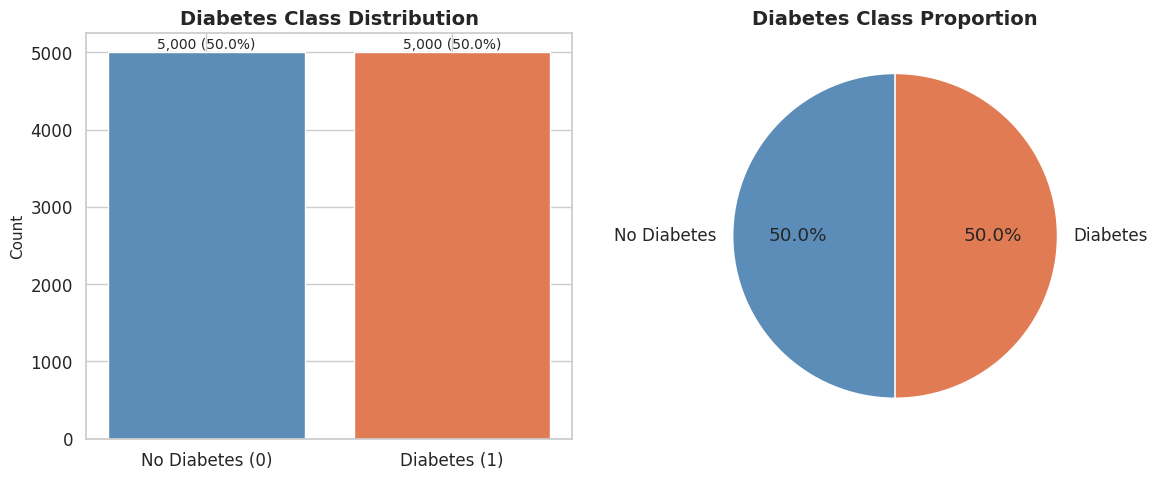

Class distribution:
 diabetes
1    5000
0    5000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df_diabetes["diabetes"].value_counts()

axes[0].bar(["No Diabetes (0)", "Diabetes (1)"], target_counts.values,
            color=[BLUE, ORANGE])
axes[0].set_title("Diabetes Class Distribution", fontsize=TITLE_SIZE, fontweight="bold")
axes[0].set_ylabel("Count", fontsize=LABEL_SIZE)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, f"{v:,} ({v/len(df_diabetes)*100:.1f}%)",
                 ha="center", fontsize=10)

axes[1].pie(target_counts.values,
            labels=["No Diabetes", "Diabetes"],
            autopct="%1.1f%%",
            colors=[BLUE, ORANGE],
            startangle=90)
axes[1].set_title("Diabetes Class Proportion", fontsize=TITLE_SIZE, fontweight="bold")

plt.tight_layout()
plt.savefig(plots_path / "diabetes_class_distribution.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("Class distribution:\n", target_counts.to_string())

#### Singular feature distributions

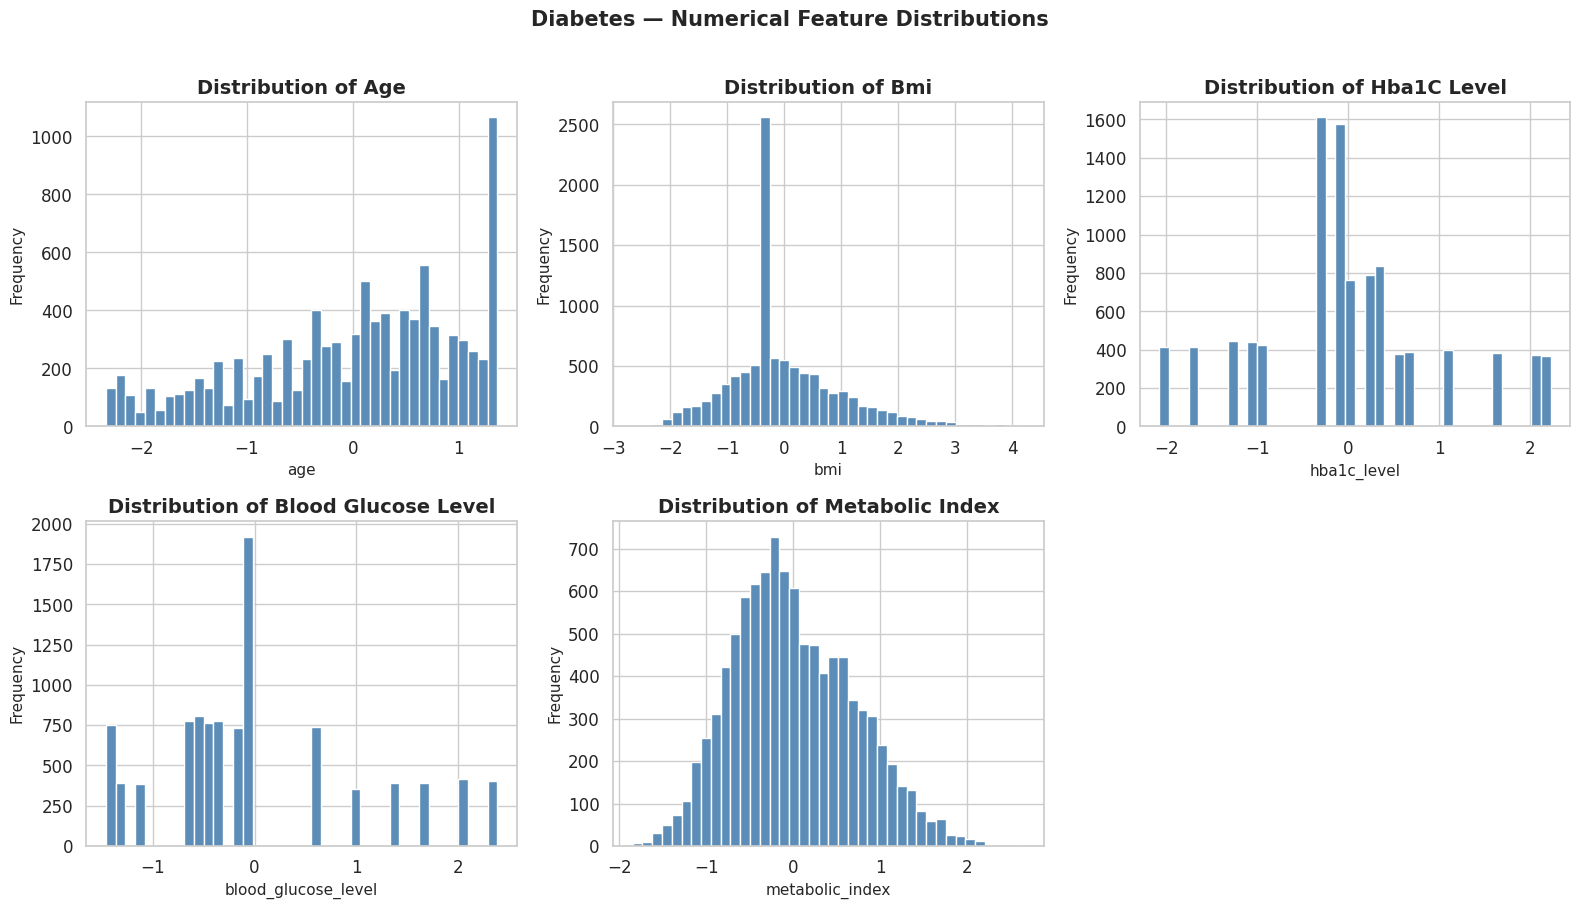

In [6]:
numerical_features = ["age", "bmi", "hba1c_level", "blood_glucose_level", "metabolic_index"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    axes[i].hist(df_diabetes[col], bins=40, color=BLUE)
    axes[i].set_title(f"Distribution of {make_title(col)}", fontsize=TITLE_SIZE, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=LABEL_SIZE)
    axes[i].set_ylabel("Frequency", fontsize=LABEL_SIZE)

axes[-1].set_visible(False)
plt.suptitle("Diabetes — Numerical Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(plots_path / "diabetes_feature_distributions.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

**Insight:** Age is fairly uniformly distributed with a concentration in older patients (60+), which is understandable from a medical standpoint as diabetes risk increases with age. Since we sampled our target variables in a balnced way, the amount of low and high risk individuals are similiar and hence other features are not really skewed in any direction.

#### Feature distributions by Class

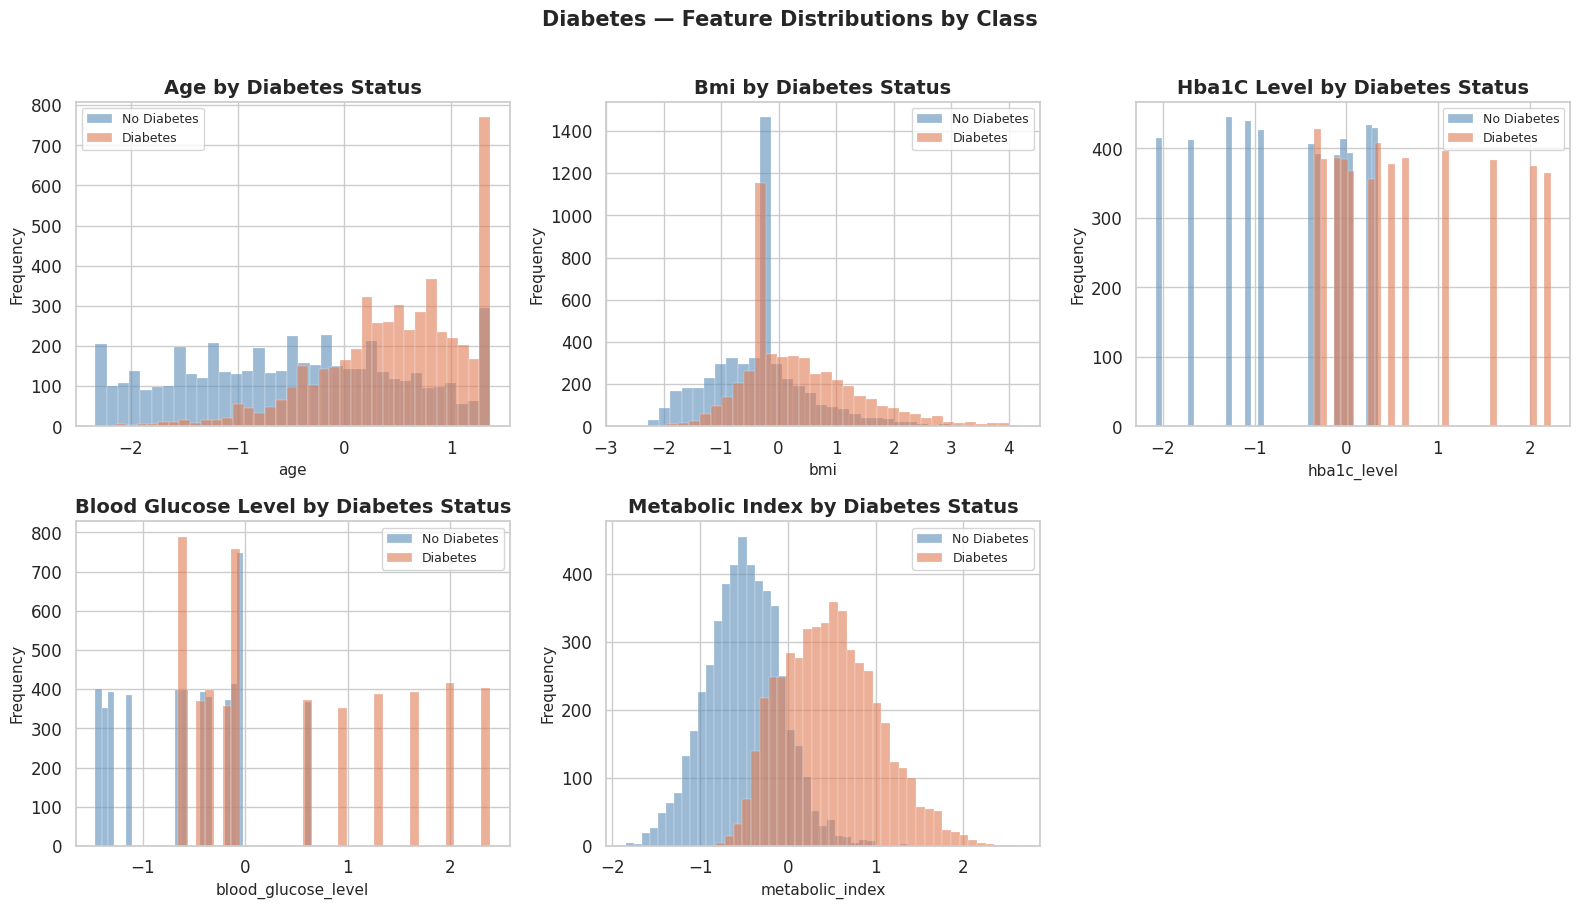

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors  = [BLUE, ORANGE]
labels  = ["No Diabetes", "Diabetes"]

for i, col in enumerate(numerical_features):
    for cls, color, label in zip([0, 1], colors, labels):
        subset = df_diabetes[df_diabetes["diabetes"] == cls][col]
        axes[i].hist(subset, bins=35, alpha=0.6, color=color,
                     label=label, edgecolor="white", linewidth=0.3)
    axes[i].set_title(f"{make_title(col)} by Diabetes Status", fontsize=TITLE_SIZE, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=LABEL_SIZE)
    axes[i].set_ylabel("Frequency", fontsize=LABEL_SIZE)
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)
plt.suptitle("Diabetes — Feature Distributions by Class", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(plots_path / "diabetes_distributions_by_class.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

**Insights:**

Age: Non-diabetic patients are uniformly spread across age groups, while diabetic patients are heavily concentrated in older age ranges, showing a clear right shift. This strongly confirms that age is a significant risk factor for diabetes.

BMI: Both classes peak around the mean but the non-diabetic distribution is much sharper and tighter, while diabetic patients have a wider distribution reaching higher BMI values. This suggests higher BMI levels is associated with diabetes but it is not as clear cut as other features.

HbA1c Level: This graph shows a clear distinction between the two classes. Non-diabetic patients cluster at lower HbA1c values while diabetic patients dominate the higher end. This means that HbA1c is the single strongest feature for predicting diabetes in this dataset, which is consistent with it being the primary clinical diagnostic marker for diabetes.

Blood Glucose Level: Similar to HbA1c, there is very clear separation between the two classes across the value range, with diabetic patients consistently appearing at higher glucose levels. This tells us that blood glucose level is also a strong marker for diabetes.

Metabolic Index: The graph is as expected since the non-diabetic patients center around -0.5 to 0 range and diabetic patients around 0.5 to 1 range. This shows that the feature correctly combines BMI, HbA1c level and blood glucose level into a single score.

#### Categorical Feature Analysis

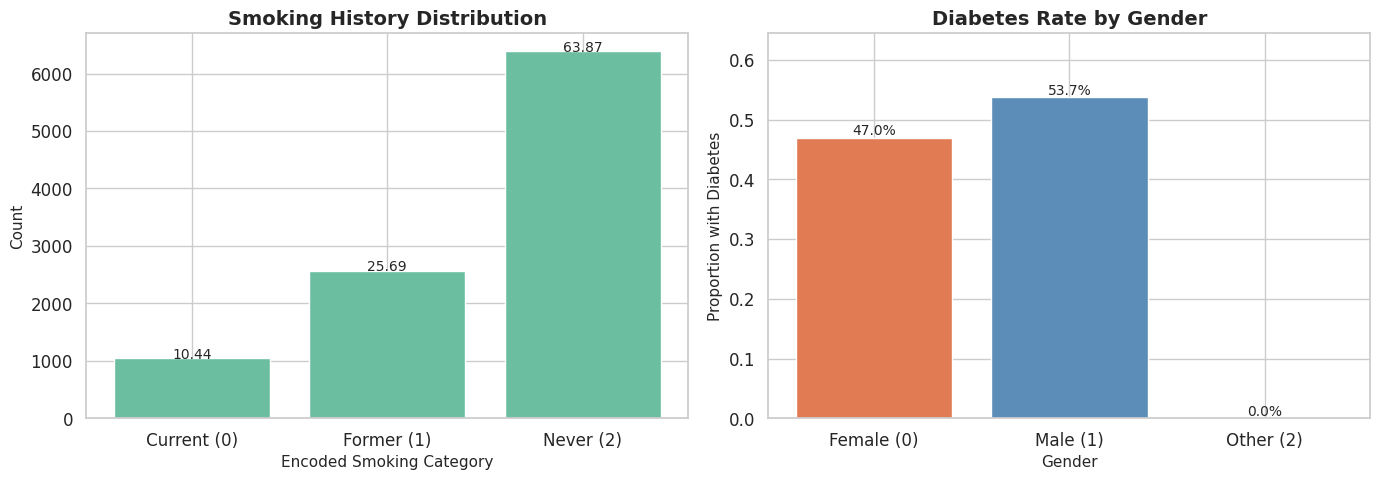

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

smoking_counts = df_diabetes["smoking_history"].value_counts().sort_index()
axes[0].bar(["Current (0)", "Former (1)", "Never (2)"], smoking_counts.values,
            color=GREEN)
axes[0].set_title("Smoking History Distribution", fontsize=TITLE_SIZE, fontweight="bold")
axes[0].set_xlabel("Encoded Smoking Category", fontsize=LABEL_SIZE)
axes[0].set_ylabel("Count", fontsize=LABEL_SIZE)
for i, v in enumerate(smoking_counts.values):
    axes[0].text(i, v + 0.005, f"{v/len(df_diabetes)*100:.2f}", ha="center", fontsize=10)

gender_diabetes = df_diabetes.groupby("gender")["diabetes"].mean().reset_index()
axes[1].bar(["Female (0)", "Male (1)", "Other (2)"], gender_diabetes["diabetes"].values,
            color=[ORANGE, BLUE, GREEN])
axes[1].set_title("Diabetes Rate by Gender", fontsize=TITLE_SIZE, fontweight="bold")
axes[1].set_xlabel("Gender", fontsize=LABEL_SIZE)
axes[1].set_ylabel("Proportion with Diabetes", fontsize=LABEL_SIZE)
max_val = gender_diabetes["diabetes"].max()
axes[1].set_ylim(0, max_val*1.2)
for i, v in enumerate(gender_diabetes["diabetes"].values):
    axes[1].text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(plots_path / "diabetes_categorical_analysis.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

**Insight:** The dataset is dominated by non-smokers. The diabetes rate is similar between genders, indicating that gender is not a strong marker for diabetes risk in this dataset.

#### Correlation Heatmap

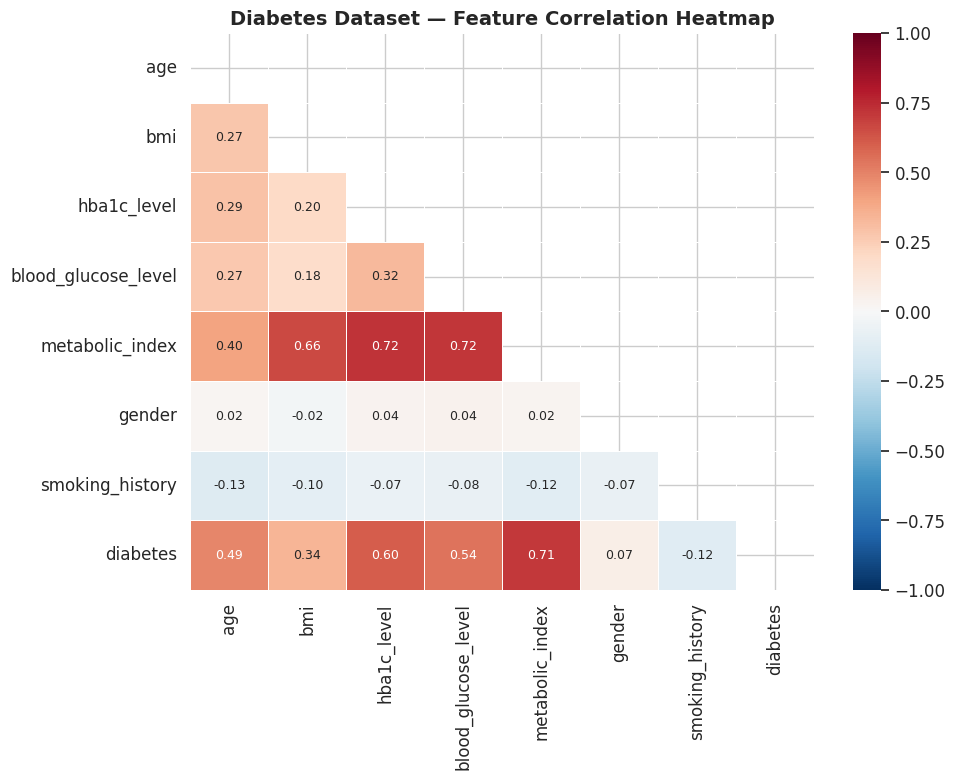

In [9]:
plt.figure(figsize=(10, 8))
corr_d = df_diabetes.select_dtypes(include=[float, int]).corr()
mask_d = np.triu(np.ones_like(corr_d, dtype=bool))
sns.heatmap(corr_d, mask=mask_d, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 9})
plt.title("Diabetes Dataset — Feature Correlation Heatmap", fontsize=TITLE_SIZE, fontweight="bold")
plt.tight_layout()
plt.savefig(plots_path / "diabetes_correlation_heatmap.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

**Insight:** The strongest positive correlations with the `diabetes` target are `hba1c_level`, `blood_glucose_level`, and `metabolic_index`, confirming their significance. There is a mild positive correlation between `age` and `diabetes`.

### 2.2 Hypertension Dataset

#### Inspecting the dataset

In [10]:
df_hypertension.describe().round(3)

,age,salt_intake,stress_score,sleep_duration,bmi,lifestyle_risk_score,bp_history,medication,family_history,exercise_level,smoking_status,has_hypertension
count,1985.000,1985.000,1985.000,1985.000,1985.000,1985.000,1985.000,1985.000,1985.000,1985.000,1985.000,1985.00
mean,-0.000,-0.000,-0.000,-0.000,-0.000,0.983,1.026,2.077,0.496,1.135,0.286,0.52
std,1.000,1.000,1.000,1.000,1.000,0.680,0.774,1.293,0.500,0.715,0.452,0.50
min,-1.664,-3.024,-1.585,-3.212,-3.129,0.000,0.000,0.000,0.000,0.000,0.000,0.00
25%,-0.841,-0.668,-0.948,-0.682,-0.668,0.288,0.000,1.000,0.000,1.000,0.000,0.00
50%,-0.018,-0.016,0.007,0.031,-0.026,1.100,1.000,3.000,0.000,1.000,0.000,1.00
75%,0.857,0.686,0.962,0.680,0.684,1.325,2.000,3.000,1.000,2.000,1.000,1.00
max,1.732,3.945,1.598,3.209,3.521,2.812,2.000,4.000,1.000,2.000,1.000,1.00


#### Understanding the target variable distribution

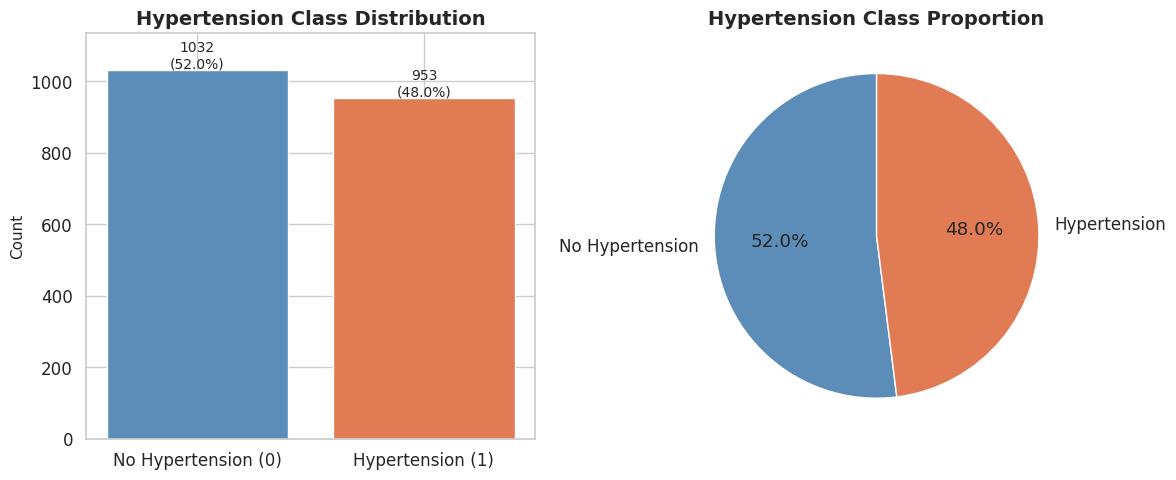

Class distribution:
 has_hypertension
1    1032
0     953


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df_hypertension["has_hypertension"].value_counts()

axes[0].bar(["No Hypertension (0)", "Hypertension (1)"], target_counts.values,
            color=[BLUE, ORANGE])
axes[0].set_title("Hypertension Class Distribution", fontsize=TITLE_SIZE, fontweight="bold")
axes[0].set_ylabel("Count", fontsize=LABEL_SIZE)
max_val = target_counts.max()
axes[0].set_ylim(0, max_val*1.1)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, f"{v}\n({v/len(df_hypertension)*100:.1f}%)",
                 ha="center", fontsize=10)

axes[1].pie(target_counts.values,
            labels=["No Hypertension", "Hypertension"],
            autopct="%1.1f%%",
            colors=[BLUE, ORANGE],
            startangle=90)
axes[1].set_title("Hypertension Class Proportion", fontsize=TITLE_SIZE, fontweight="bold")

plt.tight_layout()
plt.savefig(plots_path / "hypertension_class_distribution.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("Class distribution:\n", target_counts.to_string())

**Insight:** This dataset is relatively well-balanced between positive and negative cases, which is good for model training.

#### Singular feature distributions

In [12]:
df_hypertension.info()

<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   1985 non-null   float64
 1   salt_intake           1985 non-null   float64
 2   stress_score          1985 non-null   float64
 3   sleep_duration        1985 non-null   float64
 4   bmi                   1985 non-null   float64
 5   lifestyle_risk_score  1985 non-null   float64
 6   bp_history            1985 non-null   int64  
 7   medication            1985 non-null   int64  
 8   family_history        1985 non-null   int64  
 9   exercise_level        1985 non-null   int64  
 10  smoking_status        1985 non-null   int64  
 11  has_hypertension      1985 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 186.2 KB


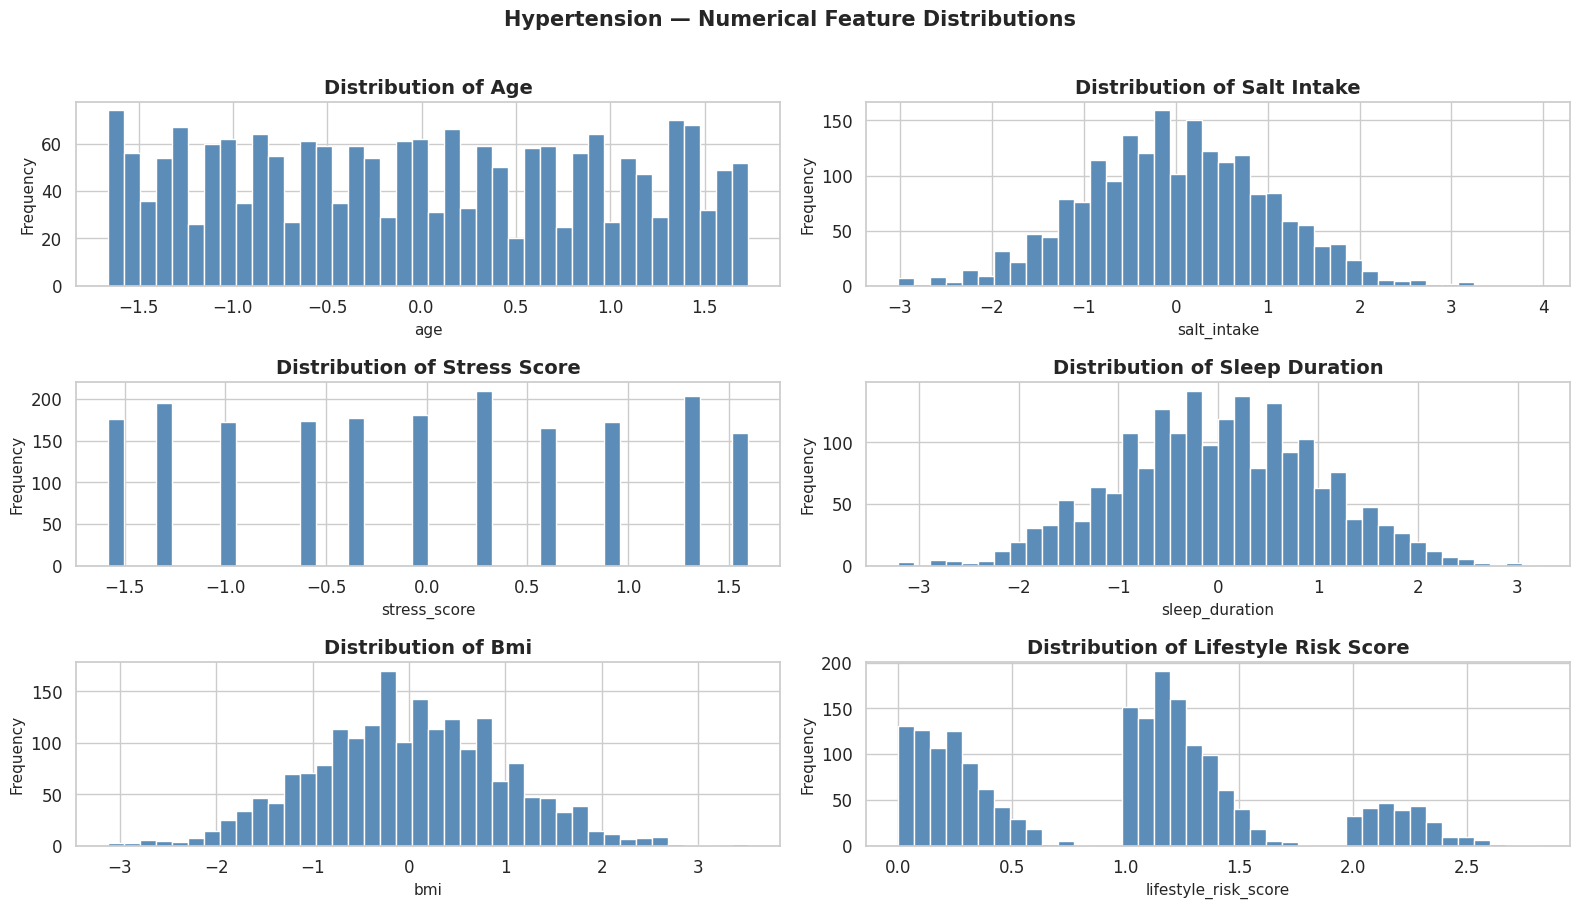

In [13]:
numerical_features = [
    "age", "salt_intake", "stress_score",
    "sleep_duration", "bmi", "lifestyle_risk_score"
]

fig, axes = plt.subplots(3, 2, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    axes[i].hist(df_hypertension[col], bins=40, color=BLUE)
    axes[i].set_title(f"Distribution of {make_title(col)}", fontsize=TITLE_SIZE, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=LABEL_SIZE)
    axes[i].set_ylabel("Frequency", fontsize=LABEL_SIZE)

plt.suptitle("Hypertension — Numerical Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(plots_path / "hypertension_feature_distributions.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

**Insights**: Age is fairly uniform, indicating that the dataset was collected across a broad range. Salt intake, BMI and sleep duration are roughly bell shaped indicating that these were also well-sampled. Individual bars in the Stress Score feature show that it was recorded using integers (probably from a scale of 0-10) and it looks normal. 

Lifestyle Risk Score feature tells us a lot about the dataset. Since the dataset peaks in the middle, we can assume most patients carry a moderate lifestyle risk. Few patients have above a 2 in the score indicating that it is rare for a patient to have all three risk factors (smoking, abnormal sleep, low exercise).

#### Feature Distributions by Target Class

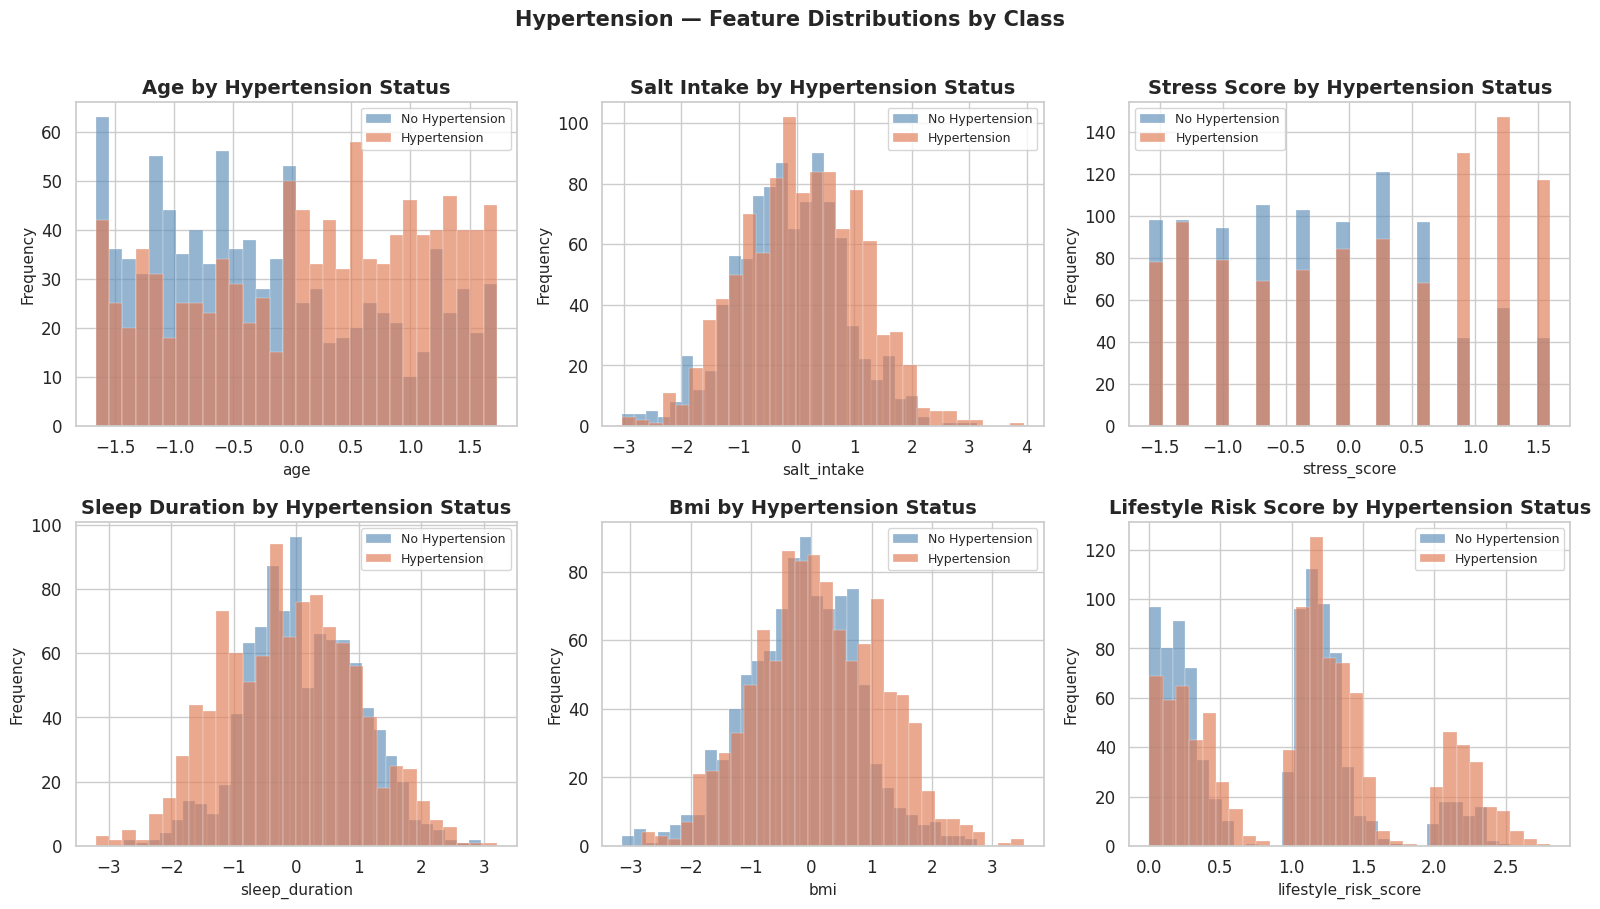

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors_h = [BLUE, ORANGE]
labels_h = ["No Hypertension", "Hypertension"]

for i, col in enumerate(numerical_features):
    for cls, color, label in zip([0, 1], colors_h, labels_h):
        subset = df_hypertension[df_hypertension["has_hypertension"] == cls][col]
        axes[i].hist(subset, bins=30, alpha=0.65, color=color,
                     label=label, edgecolor="white", linewidth=0.3)
    axes[i].set_title(f"{make_title(col)} by Hypertension Status", fontsize=TITLE_SIZE, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=LABEL_SIZE)
    axes[i].set_ylabel("Frequency", fontsize=LABEL_SIZE)
    axes[i].legend(fontsize=9)

plt.suptitle("Hypertension — Feature Distributions by Class", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(plots_path / "hypertension_distributions_by_class.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

**Insights:**
Salt intake shows only a mild right shift indicating that it is not as strong a feature as expected, however it still has correlation. Stress score clearly shows that hypertensive patients tend to relate themselves with being highly stressed. 

A very clear distinction is seen in the age feature where there are much more hypertensive patients in the later age group. 

BMI is right shifted while sleep duration is left shifted, indicating that higher BMI causes hypertension more often while lower sleep duration does the same. The sleep duration graph also tells us that although it is understood that both oversleeping and sleep deprivation can lead to hypertension but sleep deprivation clearly matters more in this dataset. 

Lifestyle Risk Score shows that patient's with higher lifestyle risk consistently have higher chances of getting diagnosed with hypertension. This validates our engineered feature.

#### Categorical Feature Analysis

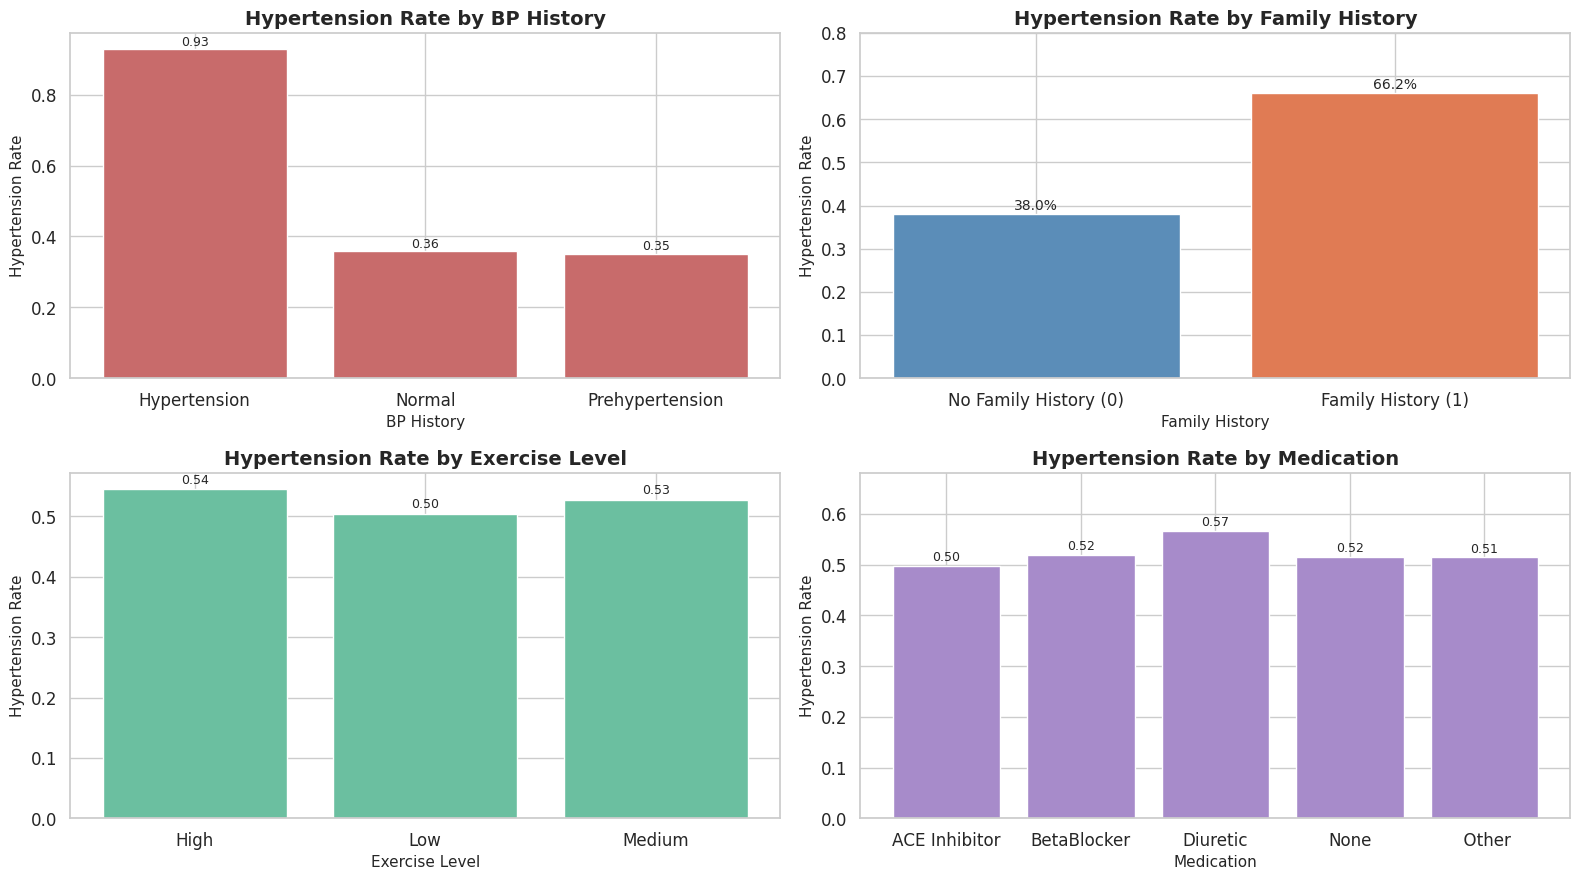

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

bp_hypertension_rate = df_hypertension.groupby("bp_history")["has_hypertension"].mean()
axes[0].bar(["Hypertension", "Normal", "Prehypertension"], bp_hypertension_rate.values, color=RED)
axes[0].set_title("Hypertension Rate by BP History", fontsize=TITLE_SIZE, fontweight="bold")
axes[0].set_xlabel("BP History", fontsize=LABEL_SIZE)
axes[0].set_ylabel("Hypertension Rate", fontsize=LABEL_SIZE)
for i, v in enumerate(bp_hypertension_rate.values):
    axes[0].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

family_hypertension_rate = df_hypertension.groupby("family_history")["has_hypertension"].mean()
axes[1].bar(["No Family History (0)", "Family History (1)"], family_hypertension_rate.values,
            color=[BLUE, ORANGE])
axes[1].set_title("Hypertension Rate by Family History", fontsize=TITLE_SIZE, fontweight="bold")
axes[1].set_xlabel("Family History", fontsize=LABEL_SIZE)
axes[1].set_ylabel("Hypertension Rate", fontsize=LABEL_SIZE)
axes[1].set_ylim(0, 0.8)
for i, v in enumerate(family_hypertension_rate.values):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=10)

exercise_hypertension_rate = df_hypertension.groupby("exercise_level")["has_hypertension"].mean()
axes[2].bar(["High", "Low", "Medium"], exercise_hypertension_rate.values, color=GREEN)
axes[2].set_title("Hypertension Rate by Exercise Level", fontsize=TITLE_SIZE, fontweight="bold")
axes[2].set_xlabel("Exercise Level", fontsize=LABEL_SIZE)
axes[2].set_ylabel("Hypertension Rate", fontsize=LABEL_SIZE)
for i, v in enumerate(exercise_hypertension_rate.values):
    axes[2].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

medication_hypertension_rate = df_hypertension.groupby("medication")["has_hypertension"].mean()
axes[3].bar(["ACE Inhibitor", "BetaBlocker", "Diuretic", "None", " Other"], medication_hypertension_rate.values, color=PURPLE)
axes[3].set_title("Hypertension Rate by Medication", fontsize=TITLE_SIZE, fontweight="bold")
axes[3].set_xlabel("Medication", fontsize=LABEL_SIZE)
axes[3].set_ylabel("Hypertension Rate", fontsize=LABEL_SIZE)
max_val = medication_hypertension_rate.max()
axes[3].set_ylim(0, max_val*1.2)
for i, v in enumerate(medication_hypertension_rate.values):
    axes[3].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(plots_path / "hypertension_categorical_analysis.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

**Insight:** Family history shows a meaningful difference in hypertension rates, confirming that hypertension has a genetic component. BP history is another strong predictor. 

Exercise level however shows a counter intuitive result. This is likely due to the lower sample size of the dataset.

Medication is almost uniform across, which is expected as people on medication likely already have hypertension. Diuretic medication shows a slight increase as compared to the others, however we still can't count it as a strong feature.

#### Correlation Heatmap

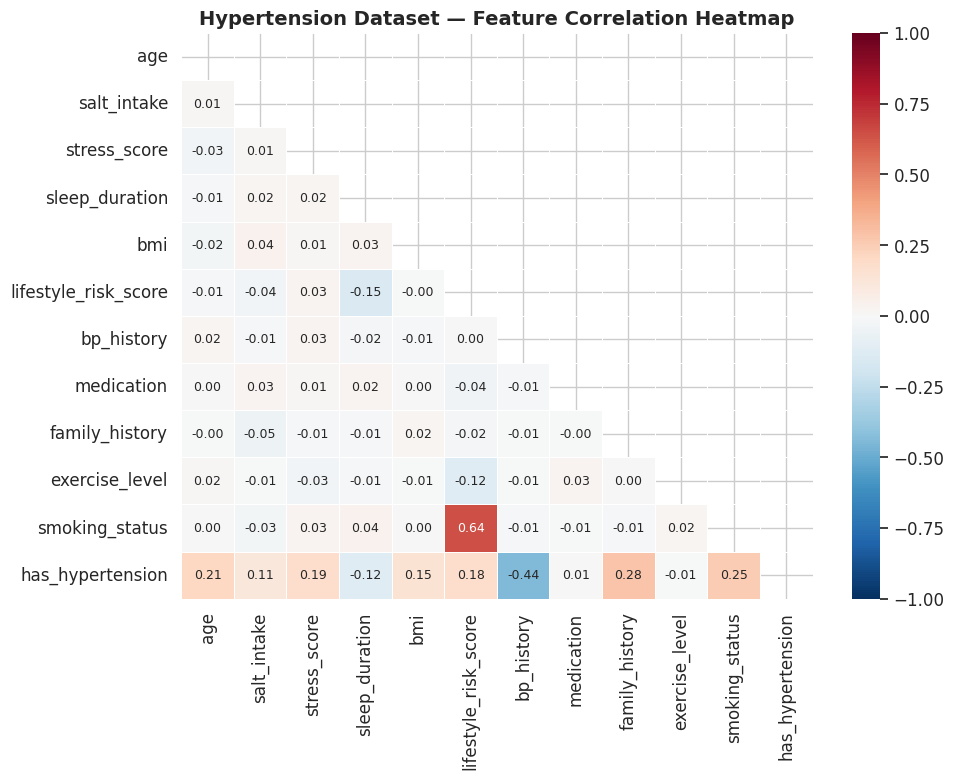

In [16]:
plt.figure(figsize=(10, 8))
corr_h = df_hypertension.select_dtypes(include=[float, int]).corr()
mask_h = np.triu(np.ones_like(corr_h, dtype=bool))
sns.heatmap(corr_h, mask=mask_h, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 9})
plt.title("Hypertension Dataset — Feature Correlation Heatmap", fontsize=TITLE_SIZE, fontweight="bold")
plt.tight_layout()
plt.savefig(plots_path / "hypertension_correlation_heatmap.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

**Insight:** `bp_history` has the strongest correlation with the target, as expected. `family_history`, `age` and `smoking_status` also show moderate positive correlations.

### 2.3 Heart Disease Dataset

#### Inspecting the dataset

In [17]:
df_heart_disease.describe().round(3)

,age,blood_pressure,cholesterol_level,diabetes,bmi,hypertension,sleep_hours,triglyceride_level,fasting_blood_sugar,crp_level,...,gender,smoking,family_heart_disease,low_hdl_cholesterol,high_ldl_cholesterol,exercise_habits,alcohol_consumption,stress_level,sugar_consumption,heart_disease_status
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,...,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,-0.000,0.000,-0.000,0.495,-0.000,0.505,0.000,0.000,-0.000,-0.000,...,0.502,0.515,0.498,0.502,0.494,2.013,1.477,1.995,1.991,0.444
std,1.000,1.000,1.000,0.500,1.000,0.500,1.000,1.000,1.000,1.000,...,0.500,0.500,0.500,0.500,0.500,0.817,1.119,0.812,0.822,0.497
min,-1.723,-1.695,-1.734,0.000,-1.758,0.000,-1.708,-1.734,-1.704,-1.723,...,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,1.000,0.000
25%,-0.842,-0.898,-0.883,0.000,-0.858,0.000,-0.877,-0.859,-0.897,-0.874,...,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,1.000,0.000
50%,-0.016,0.014,0.013,0.000,0.000,1.000,0.007,-0.008,-0.006,-0.000,...,1.000,1.000,0.000,1.000,0.000,2.000,1.000,2.000,2.000,0.000
75%,0.864,0.868,0.864,1.000,0.862,1.000,0.878,0.866,0.885,0.870,...,1.000,1.000,1.000,1.000,1.000,3.000,2.000,3.000,3.000,1.000
max,1.690,1.723,1.714,1.000,1.733,1.000,1.718,1.717,1.692,1.736,...,1.000,1.000,1.000,1.000,1.000,3.000,3.000,3.000,3.000,1.000


#### Understanding the Target Variable Distribution

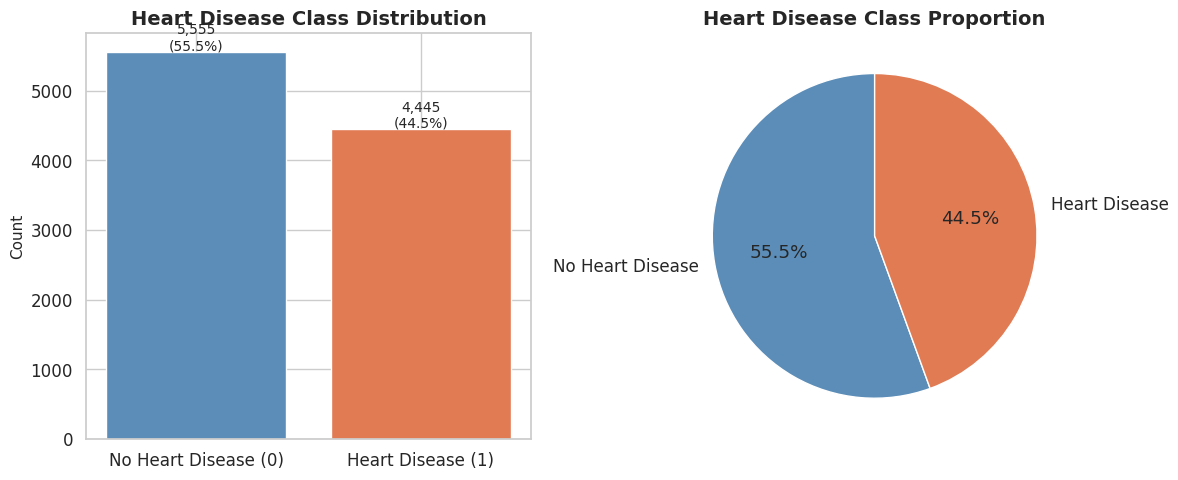

Class distribution:
 heart_disease_status
0    5555
1    4445


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df_heart_disease["heart_disease_status"].value_counts()

axes[0].bar(["No Heart Disease (0)", "Heart Disease (1)"], target_counts.values,
            color=[BLUE, ORANGE])
axes[0].set_title("Heart Disease Class Distribution", fontsize=TITLE_SIZE, fontweight="bold")
axes[0].set_ylabel("Count", fontsize=LABEL_SIZE)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 30, f"{v:,}\n({v/len(df_heart_disease)*100:.1f}%)",
                 ha="center", fontsize=10)

axes[1].pie(target_counts.values,
            labels=["No Heart Disease", "Heart Disease"],
            autopct="%1.1f%%",
            colors=[BLUE, ORANGE],
            startangle=90)
axes[1].set_title("Heart Disease Class Proportion", fontsize=TITLE_SIZE, fontweight="bold")

plt.tight_layout()
plt.savefig(plots_path / "heartdisease_class_distribution.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("Class distribution:\n", target_counts.to_string())

**Insights:** The heart disease dataset is slightly imbalanced, with a 10% difference between classes. This is more realistic than a 50/50 split since heart disease only affects a minority of people.

However, this will cause a problem for model training. We can take care of this during the model training process by using class weights or using SMOTE. 

#### Singular feature distributions

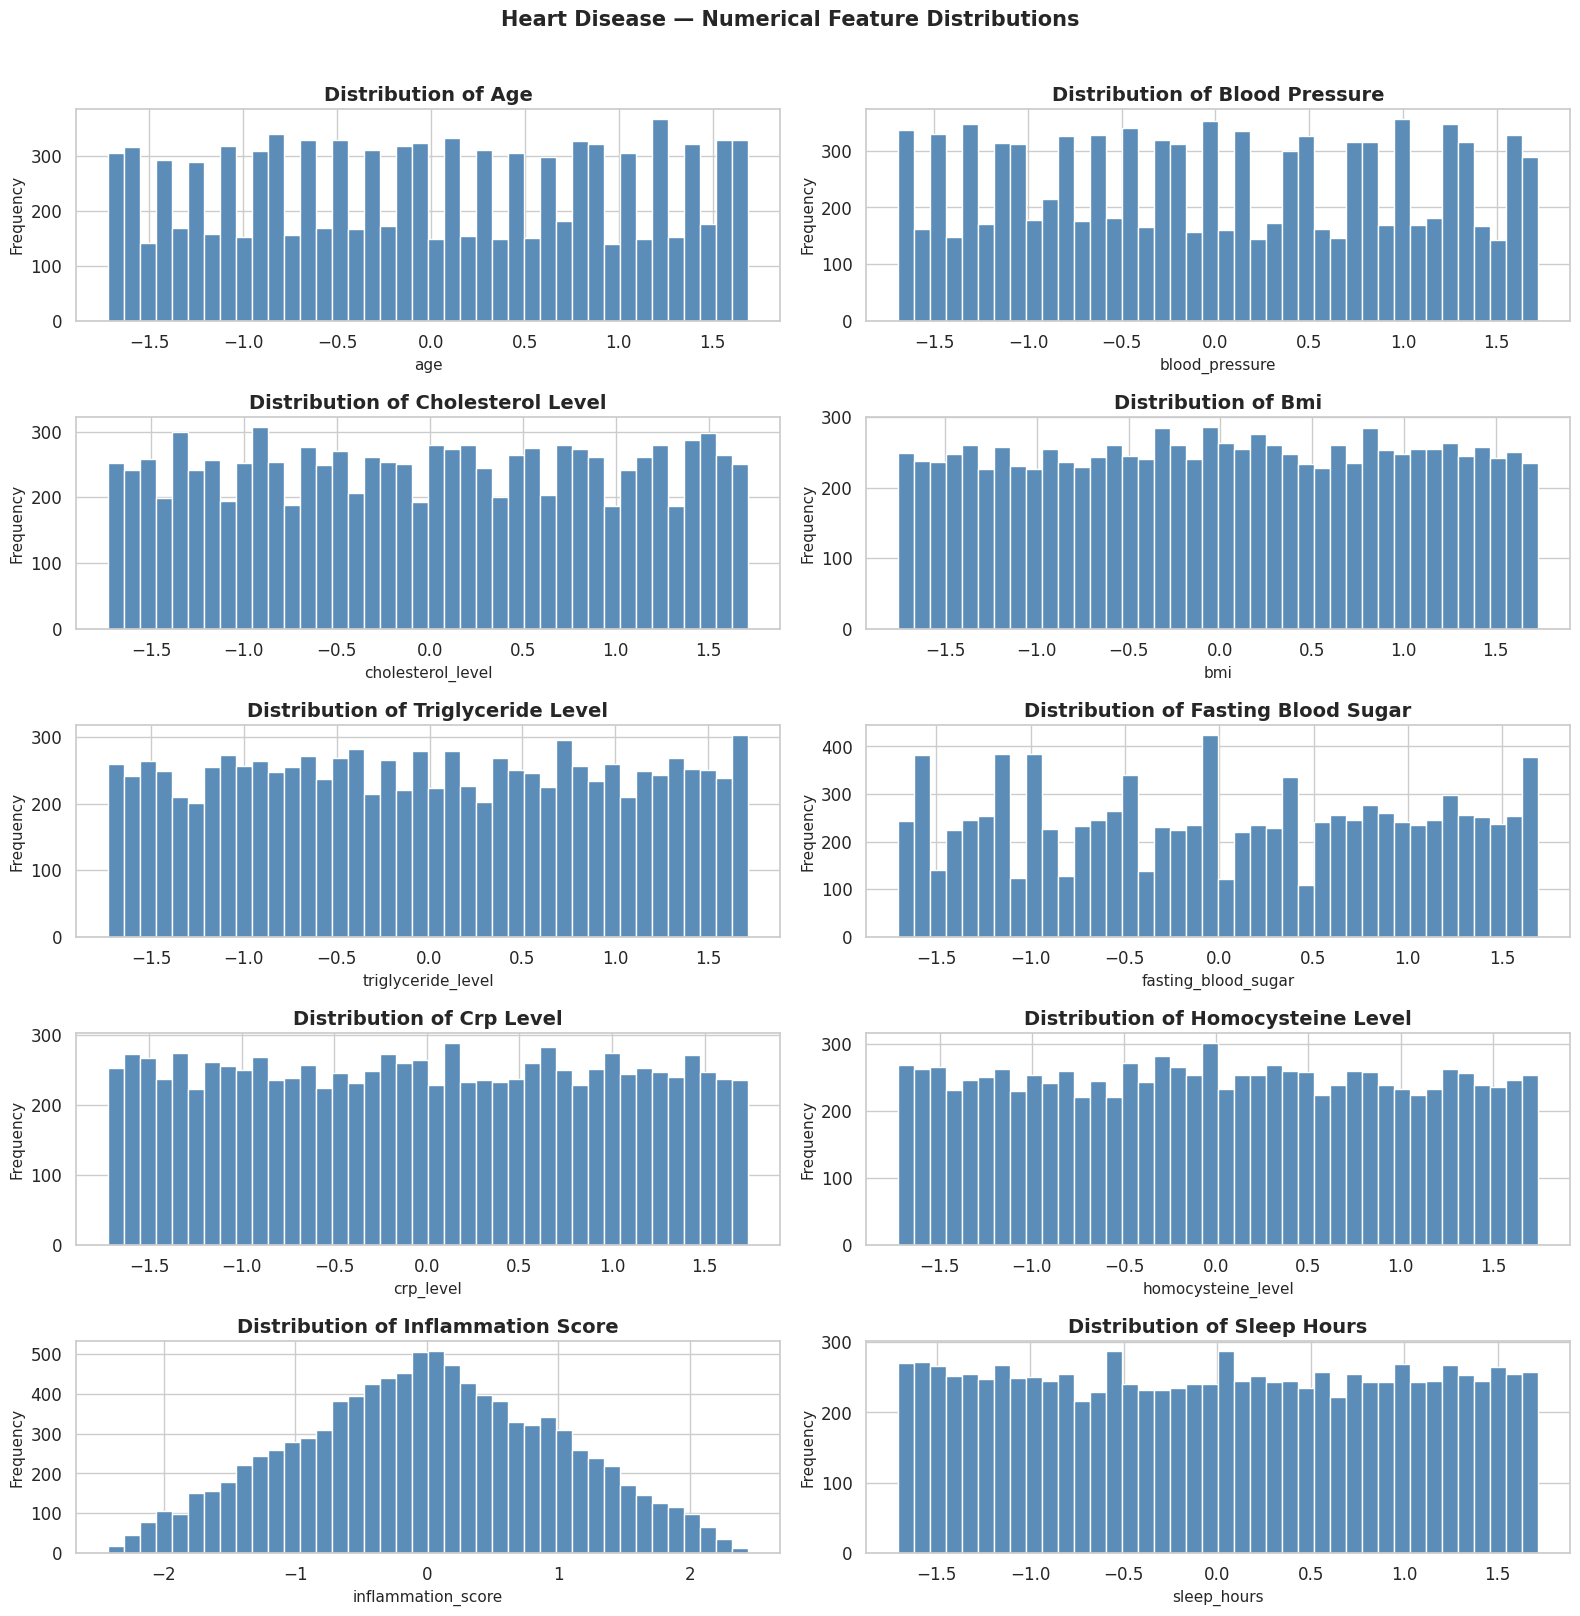

In [19]:
numerical_features = [
    "age", "blood_pressure", "cholesterol_level", "bmi",
    "triglyceride_level", "fasting_blood_sugar", "crp_level",
    "homocysteine_level", "inflammation_score", "sleep_hours"
]

fig, axes = plt.subplots(5, 2, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    axes[i].hist(df_heart_disease[col], bins=40, color=BLUE)
    axes[i].set_title(f"Distribution of {make_title(col)}", fontsize=TITLE_SIZE, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=LABEL_SIZE)
    axes[i].set_ylabel("Frequency", fontsize=LABEL_SIZE)

plt.suptitle("Heart Disease — Numerical Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(plots_path / "heart_disease_feature_distributions.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

**Insights:** We can see that most features in this dataset are unusually uniform across all classes. This could mean that this dataset was deliberately balanced across all features.

Fasting blood sugar shows irregular clusters, towards the left but starts becoming more uniform towards the right, showing a slight correlation.

Inflammation score shows expected behaviour as it is an engineered feature constituting multiple uniform features, this resulting in a bell-shaped distribution.

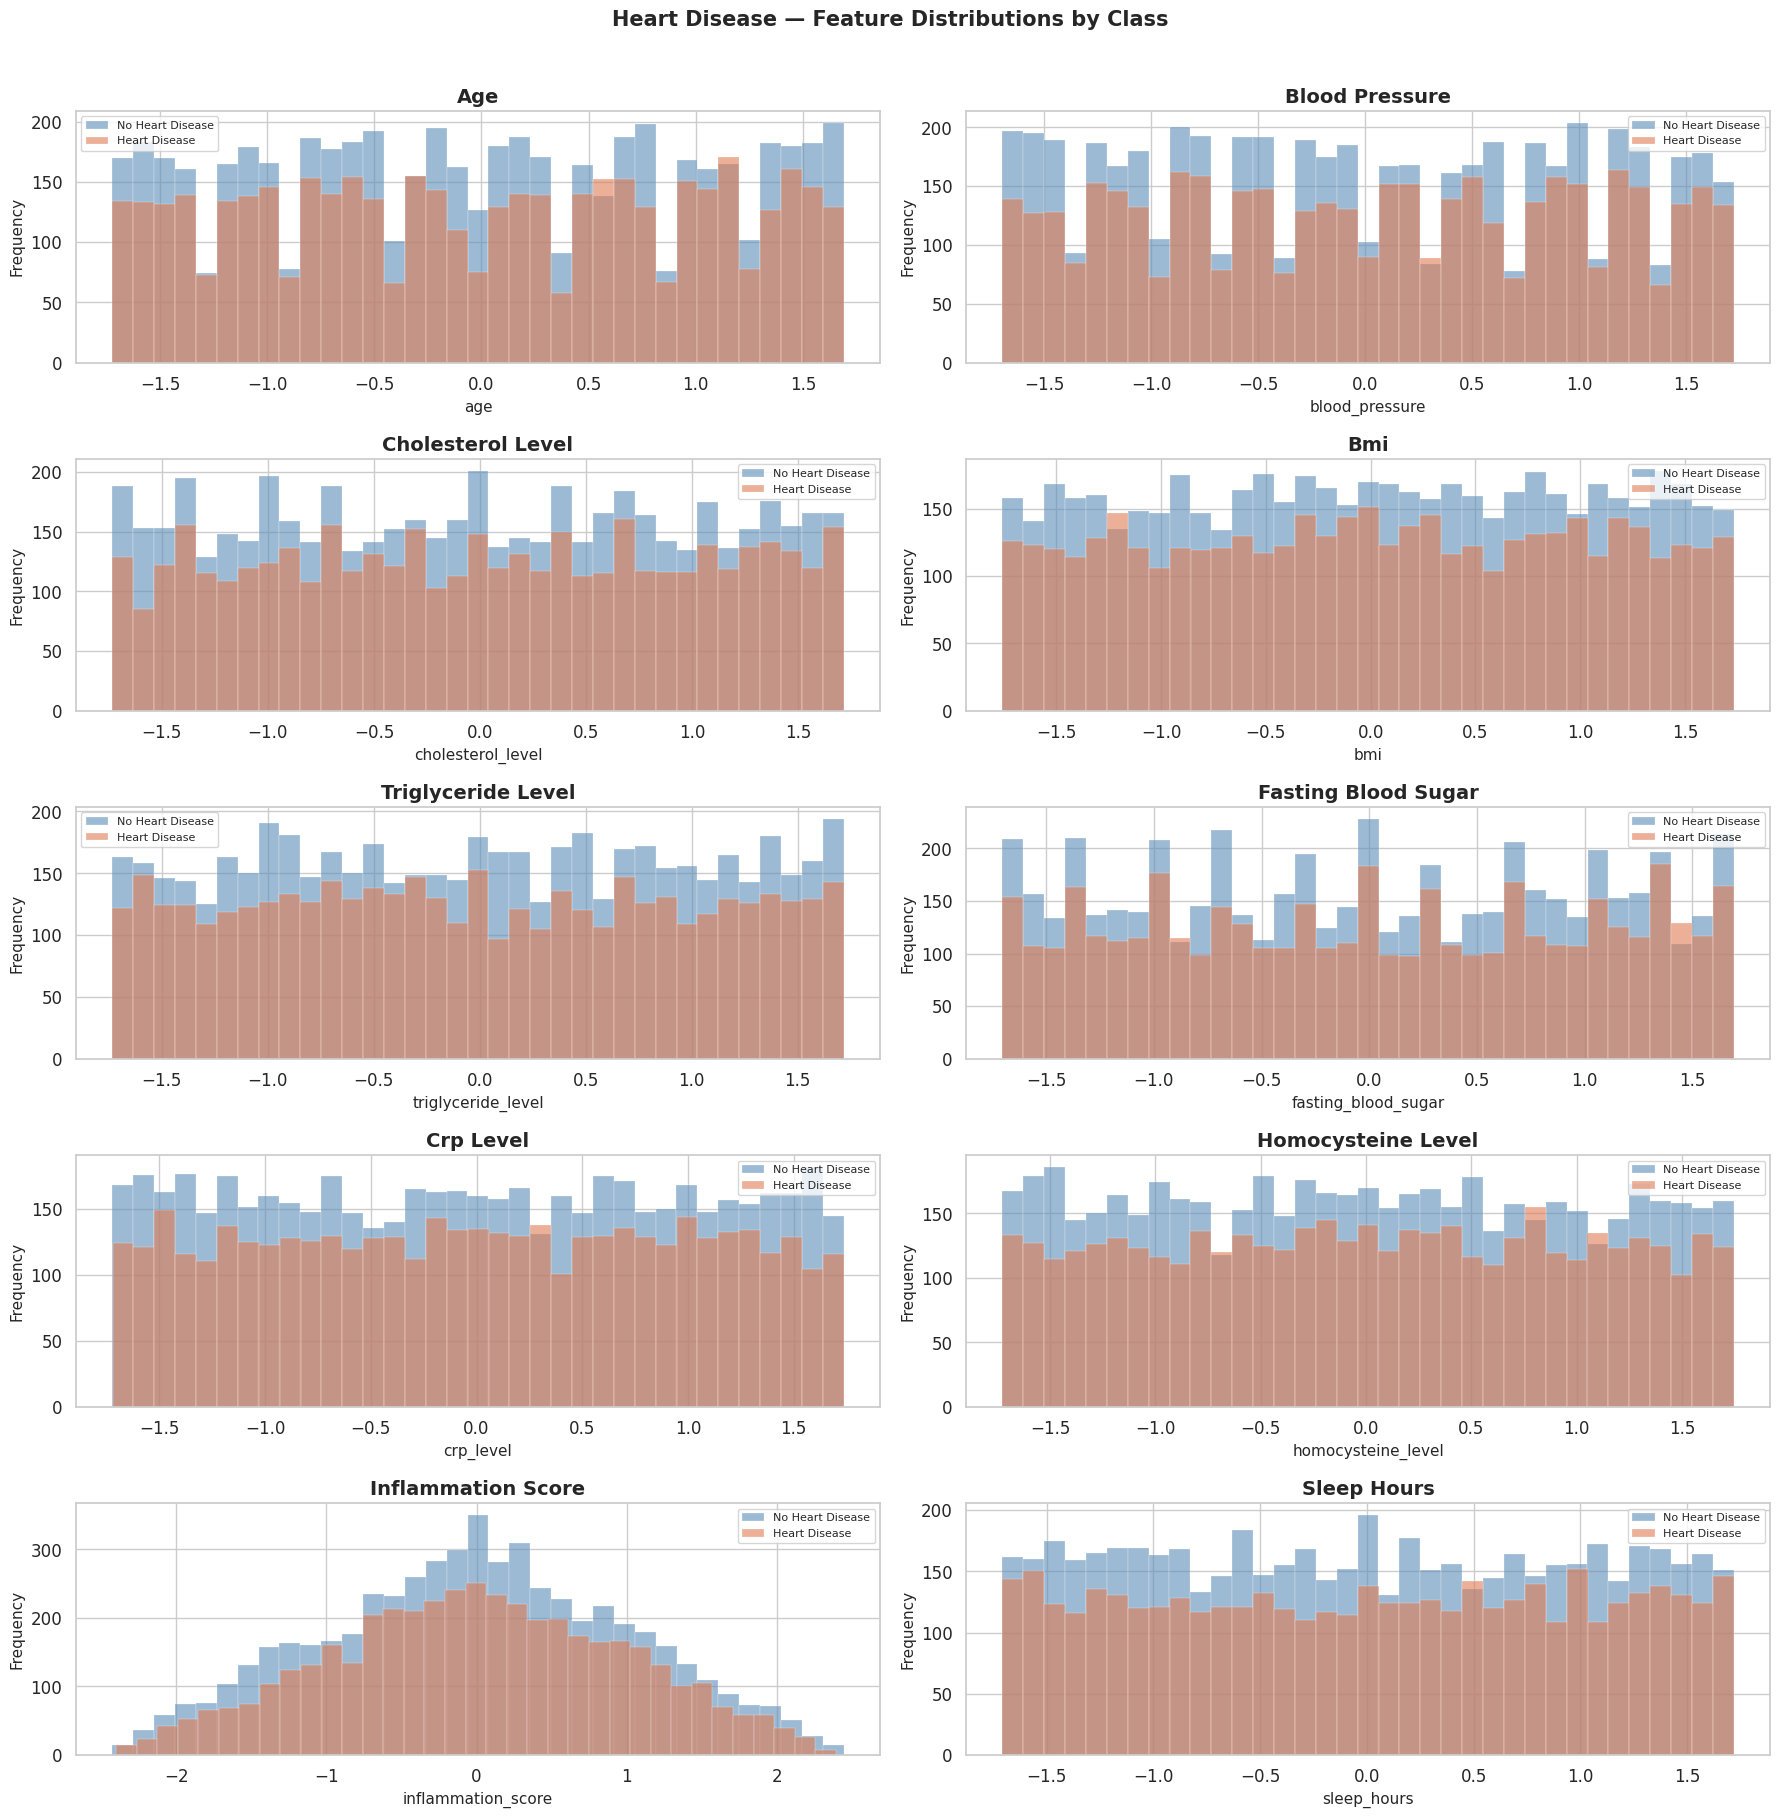

In [20]:
fig, axes = plt.subplots(5, 2, figsize=(18, 18))
axes = axes.flatten()

colors_hd = [BLUE, ORANGE]
labels_hd = ["No Heart Disease", "Heart Disease"]

for i, col in enumerate(numerical_features):
    for cls, color, label in zip([0, 1], colors_hd, labels_hd):
        subset = df_heart_disease[df_heart_disease["heart_disease_status"] == cls][col]
        axes[i].hist(subset, bins=35, alpha=0.6, color=color,
                     label=label, edgecolor="white", linewidth=0.3)
    axes[i].set_title(f"{make_title(col)}", fontsize=TITLE_SIZE, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=LABEL_SIZE)
    axes[i].set_ylabel("Frequency", fontsize=LABEL_SIZE)
    axes[i].legend(fontsize=8)

plt.suptitle("Heart Disease — Feature Distributions by Class",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(plots_path / "heart_disease_distributions_by_class.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

**Insight:** There is almost a complete lack of separation between each class for every feature distribution. This highly indicates that this dataset was synthetically created. To counteract this for model training, our model needs to rely more on engineered features and proper algorithms such as Random Forest, rather than simple regression. 

#### Diabetes and Hypertension vs Heart Disease

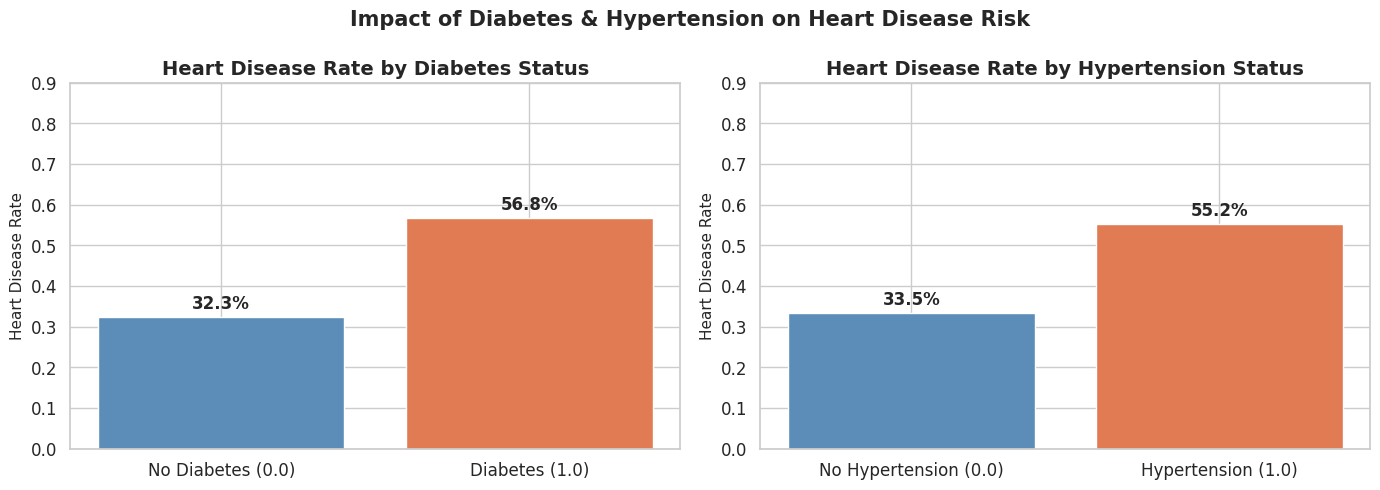

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

diabetes_heart = df_heart_disease.groupby("diabetes")["heart_disease_status"].mean().reset_index()
axes[0].bar(["No Diabetes (0.0)", "Diabetes (1.0)"],
            diabetes_heart["heart_disease_status"].values,
            color=[BLUE, ORANGE])
axes[0].set_title("Heart Disease Rate by Diabetes Status", fontsize=TITLE_SIZE, fontweight="bold")
axes[0].set_ylabel("Heart Disease Rate", fontsize=LABEL_SIZE)
axes[0].set_ylim(0, 0.9)
for i, v in enumerate(diabetes_heart["heart_disease_status"].values):
    axes[0].text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=12, fontweight="bold")

hypertension_heart = df_heart_disease.groupby("hypertension")["heart_disease_status"].mean().reset_index()
axes[1].bar(["No Hypertension (0.0)", "Hypertension (1.0)"],
            hypertension_heart["heart_disease_status"].values,
            color=[BLUE, ORANGE])
axes[1].set_title("Heart Disease Rate by Hypertension Status", fontsize=TITLE_SIZE, fontweight="bold")
axes[1].set_ylabel("Heart Disease Rate", fontsize=LABEL_SIZE)
axes[1].set_ylim(0, 0.9)
for i, v in enumerate(hypertension_heart["heart_disease_status"].values):
    axes[1].text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=12, fontweight="bold")

plt.suptitle("Impact of Diabetes & Hypertension on Heart Disease Risk",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(plots_path / "heart_disease_diabetes_hypertension_impact.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

**Insights:** As we can see from the graph above, patients with diabetes and hypertension are significantly at more risk than patients without. This validates the aim of our model, to predict probability of heart disease with respect to diabetes and hypertension.

In [22]:
df_heart_disease["stress_level"].unique()

array([2, 3, 1])

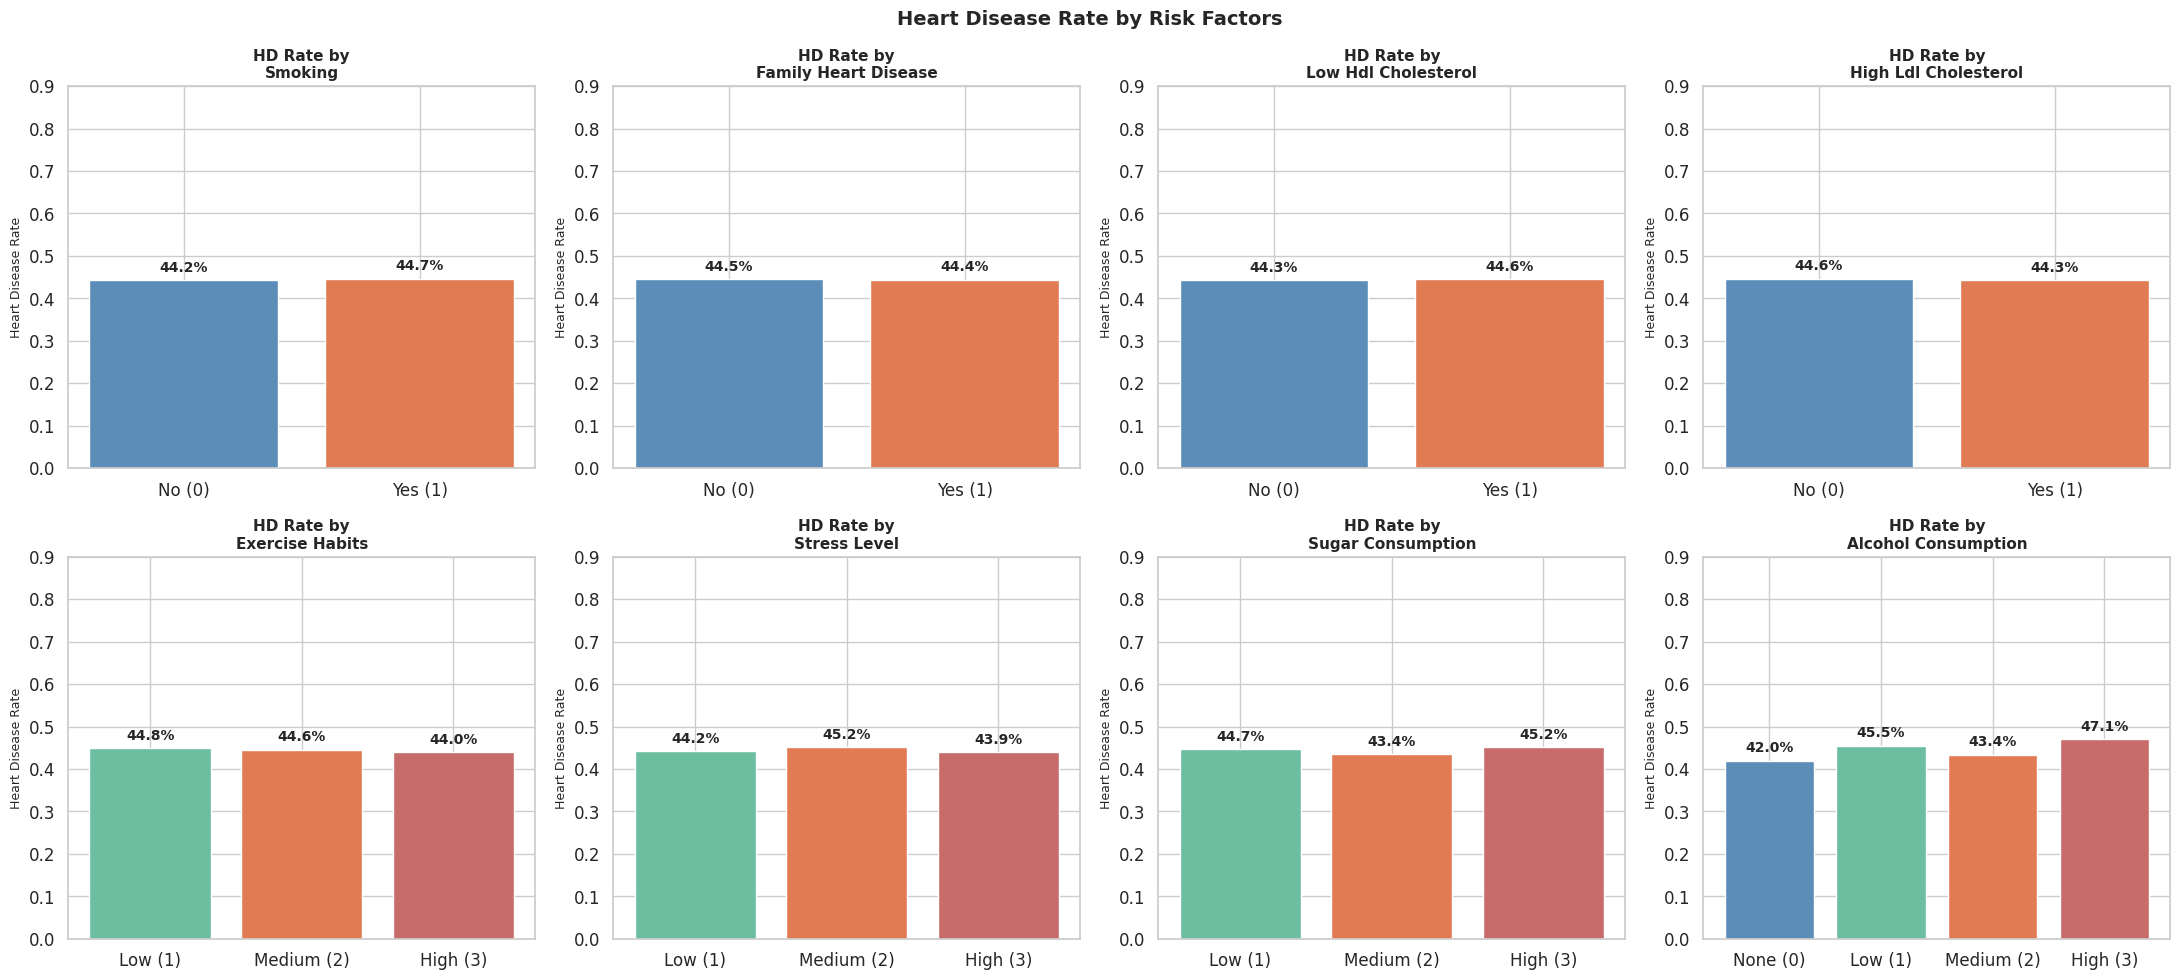

In [23]:
categorical_features = [
    "smoking", "family_heart_disease",
    "low_hdl_cholesterol", "high_ldl_cholesterol"
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    rate = df_heart_disease.groupby(col)["heart_disease_status"].mean()
    axes[i].bar(["No (0)", "Yes (1)"], rate.values, color=[BLUE, ORANGE])
    axes[i].set_title(f"HD Rate by\n{make_title(col)}", fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Heart Disease Rate", fontsize=9)
    axes[i].set_ylim(0, 0.9)
    for j, v in enumerate(rate.values):
        axes[i].text(j, v + 0.02, f"{v:.1%}", ha="center", fontsize=10, fontweight="bold")

labels_no_none = ["Low (1)", "Medium (2)", "High (3)"]
for i, col in enumerate(["exercise_habits", "stress_level", "sugar_consumption"]):
    rate = df_heart_disease.groupby(col)["heart_disease_status"].mean()
    axes[4 + i].bar(labels_no_none, rate.values, color=[GREEN, ORANGE, RED])
    axes[4 + i].set_title(f"HD Rate by\n{make_title(col)}", fontsize=11, fontweight="bold")
    axes[4 + i].set_ylabel("Heart Disease Rate", fontsize=9)
    axes[4 + i].set_ylim(0, 0.9)
    for j, v in enumerate(rate.values):
        axes[4 + i].text(j, v + 0.02, f"{v:.1%}", ha="center", fontsize=10, fontweight="bold")

labels_with_none = ["None (0)", "Low (1)", "Medium (2)", "High (3)"]
alc_rate = df_heart_disease.groupby("alcohol_consumption")["heart_disease_status"].mean()
axes[7].bar(labels_with_none, alc_rate.values, color=[BLUE, GREEN, ORANGE, RED])
axes[7].set_title("HD Rate by\nAlcohol Consumption", fontsize=11, fontweight="bold")
axes[7].set_ylabel("Heart Disease Rate", fontsize=9)
axes[7].set_ylim(0, 0.9)
for j, v in enumerate(alc_rate.values):
    axes[7].text(j, v + 0.02, f"{v:.1%}", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Heart Disease Rate by Risk Factors", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(plots_path / "heart_disease_categorical_analysis.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

**Insights:** All features shown above further indicate the synthetic nature of this dataset.

#### Correlation Heatmap

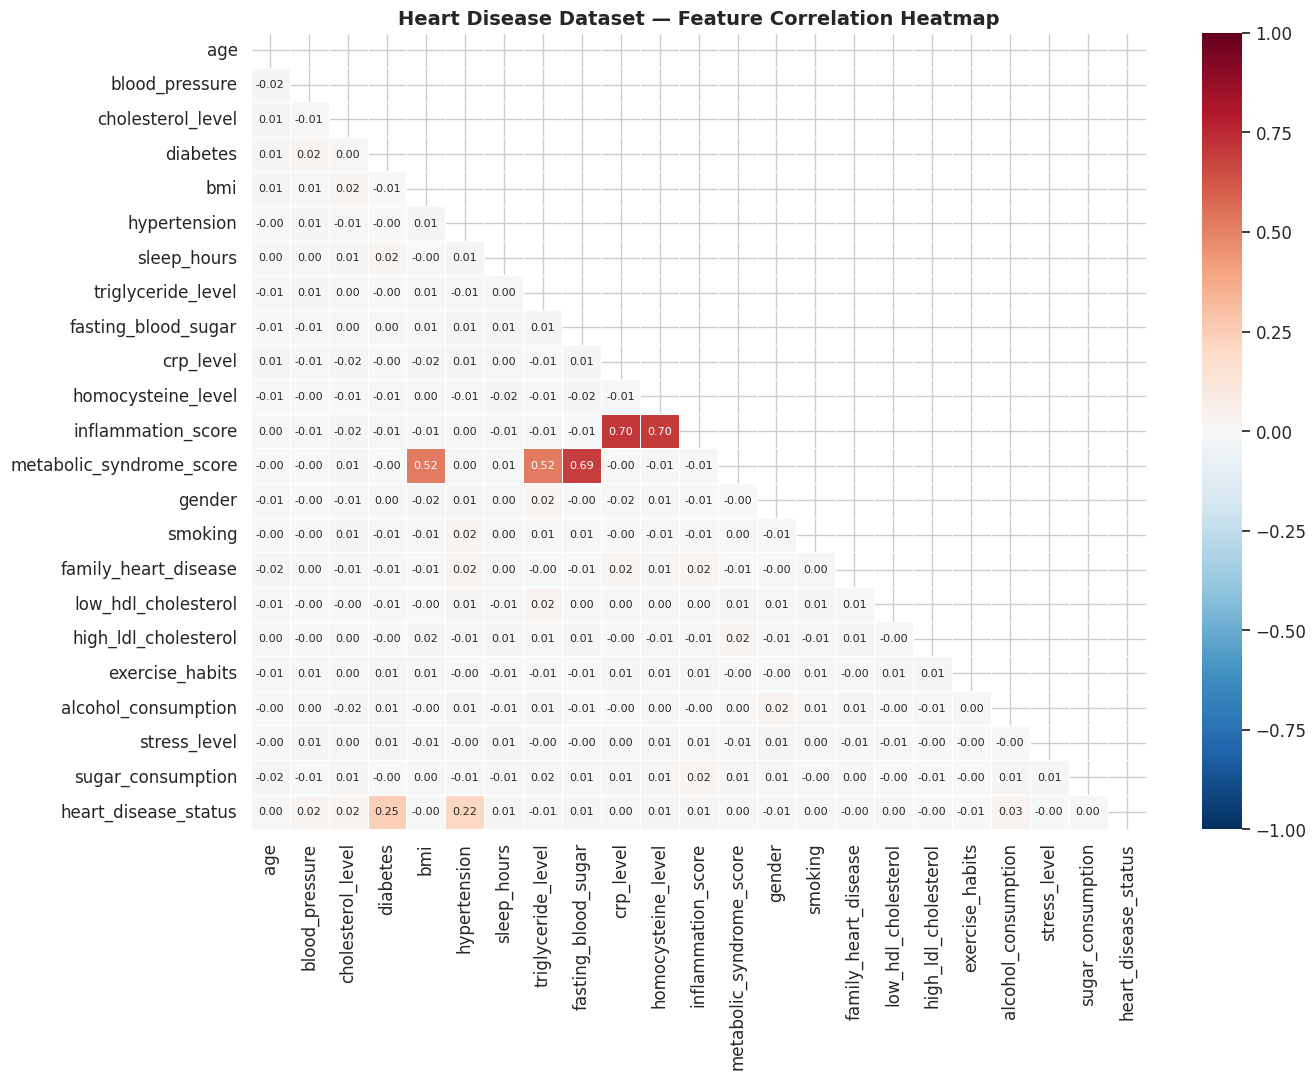

In [24]:
plt.figure(figsize=(14, 11))
corr_hd = df_heart_disease.select_dtypes(include=[float, int]).corr()
mask_hd = np.triu(np.ones_like(corr_hd, dtype=bool))
sns.heatmap(corr_hd, mask=mask_hd, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 8})
plt.title("Heart Disease Dataset — Feature Correlation Heatmap",
          fontsize=TITLE_SIZE, fontweight="bold")
plt.tight_layout()
plt.savefig(plots_path / "heart_disease_correlation_heatmap.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()

**Insights:** As expected from the results above, `heart_disease_status` only has a correlation between `diabetes` and `hypertension`.

This is problematic for our model, and will need proper class weights and model building to be successful.

## 3. Summary

**Diabetes:** The strongest correlations with the target are `hba1c_level`, `blood_glucose_level`, and `metabolic_index`, confirming their clinical significance. A mild positive correlation is also observed with age.

**Hypertension:** `bp_history` has the strongest correlation with the target, with `family_history`, `age`, and `smoking_status` also showing moderate positive correlations, giving this sub-model a reliable set of predictors.

**Heart Disease:** Meaningful correlations with the target exist almost exclusively for `diabetes` and `hypertension`, with the remaining features contributing very little signal due to the synthetic nature of the dataset. This places critical importance on the two sub-models providing accurate probability estimates, as they represent the strongest available predictors for the final heart disease prediction.